# Information Visualization I 
## School of Information, University of Michigan

## Week 3: 
- Perception / Cognition

## Assignment Overview
### This assignment's objectives include:

- Review, refect, and apply the concepts of the perception pipeline. Justify how different encodings impact the effectiveness of a visualization depending on the human perception process.

!["Drawing"](/voc/data/preattentive_resized.png)

<p style="text-align: center;"> Preattentive Processing </p>

- Recreate visualizations and propose new and alternative visualizations using [Altair](https://altair-viz.github.io/) 

### The total score of this assignment will be 100 points consisting of:
- Case study reflection: America's Favorite 'Star Wars' Movies (And Least Favorite Characters) (25 points)
- Altair programming exercise (75 points)

### Resources:
- Article by [FiveThirtyEight](https://fivethirtyeight.com) available  [online](https://fivethirtyeight.com/features/americas-favorite-star-wars-movies-and-least-favorite-characters/) (Hickey, 2014)  
- Datasets from FiveThirtyEight, we have downloaded a subset of this data in the folder [./assets](assets)
    - The original dataset can be found at [FiveThirtyEight Star Wars Survey](https://github.com/fivethirtyeight/data/tree/master/star-wars-survey)
    

### Important notes:
1) There will be a couple of places where the numbers you get when you select rows may be a little different than 538, but the percents should still work (e.g., 828 instead of 834). You'll see this in our examples. If you can somehow get the data to match exactly, that's great too.

2) A lot of this assignment will be based on building "compound" charts. Using the wrong strategy will mean that you are spending a lot of time "cleaning up" charts. We strongly suggest reading through (and understanding) the Altair documentation [on this](https://altair-viz.github.io/user_guide/compound_charts.html).

3) Grading for this assignment is entirely done by a human grader. They will be running tests on the functions we ask you to create. This means there is no autograding (submitting through the autograder will result in an error). You are expected to test and validate your own code. 

4) Keep your notebooks clean and readable. If your code is highly messy or inefficient you will get a deduction.

5) Follow the instructions for submission on Coursera. You will be providing us a generated link to a read-only version of your notebook and a PDF. When turning in your PDF, please use the File -> Print -> Save as PDF option ***from your browser***. Do ***not*** use the File->Download as->PDF option. Complete instructions for this are under Resources in the Coursera page for this class. If you're having trouble with printing, take a look at [this video](https://youtu.be/PiO-K7AoWjk).

## Part 1. Perception and Cognition (25 points)
Read the article ["America’s Favorite ‘Star Wars’ Movies (And Least Favorite Characters),"](https://fivethirtyeight.com/features/americas-favorite-star-wars-movies-and-least-favorite-characters/) and answer the following questions:


### 1.1 List the different data types in the following visualizations and their encodings (10 points)
Look at the following visualizations. For each, list the variable, their type, and the encoding used. 

!["How rate visualization"](/voc/data/how_rate_resized.png)
!["Have seen visualization"](/voc/data/have_seen_resized.png)

Use the following table for each variable (indicate which vis each came from):
* variable name, variable type (e.g., ordinal, nominal, etc.), variable encoding (e.g., color, x-position, etc.)

For example, if you [look at this visualization](https://altair-viz.github.io/gallery/scatter_tooltips.html) one row in our table below would be: Horsepower, quantitative, x-position.

_1.1 Answer_

*Use as many rows as you need*

How People Rate the 'Star Wars' Movies

| Variable name| Variable Type (Ordinal/Nominal/Quantitative) | Variable encoding (color, x-position, etc.) |
| --- | --- | --- |
|  Star Wars Film | Nominal | Y |
|  Ranking Category | Ordinal | color (hue) |
|  Percent (for each third) | Quant | X |


Which 'Star Wars' Movies Have You Seen?

| Variable name| Variable Type (Ordinal/Nominal/Quantitative) | Variable encoding (color, x-position, etc.) |
| --- | --- | --- |
|  Star Wars Film | Nominal | Y |
|  Seen % | Quantitative | X |



### 1.2 A Pie Chart Version (15 points)


!["Drawing"](/voc/data/have_seen_resized.png)

Your colleague is arguing that the chart above could be made more *effective* by using one or more pie charts. In what situations are they right? In what situations would they be wrong? If it helps makes your case, feel free to create a picture (hand drawn is fine) and load it into the notebook.

The domain task/question of the above chart is attempting to answer "of respondents who have seen a Star Wars film, which film has been seen the most (count 1 per respondent)?". A pie chart is acceptable when you are trying to express a variable as a % of a whole. In the situation above, a pie chart would be ineffective because respondents who have seen any film could select all that apply. This would result in a pie chart where the sum of the counts of each film would exceed the respondents total. It would also be less effective if you were to create 6 concatenated pie charts (one for each film, see pic below) with two areas- % have seen film and % have not. It would be less effective because it would be harder to compare which films are the most watched. In order for the pie chart to be an effective visualization, you would have to change the domain task/question. A pie chart would be effective for a question along the lines of "which stars wars film did you watch first?", as it can be expressed as each film being a percent of a single total. Another way to make a pie chart effective in this situation is to change the total. Instead of making the denominator 835 (respondent total), the total could expressed as count of all films seen. The expression of the pie chart would be slightly different as instead of answering "Which films have you seen?", it would roughly become "what is the probability that a respondent has seen a film".

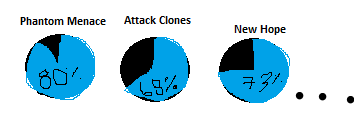

## Part 2. Altair programming exercise (75 points)
We have provided you with some code and parts of the article [America’s Favorite ‘Star Wars’ Movies (And Least Favorite Characters)](https://fivethirtyeight.com/features/americas-favorite-star-wars-movies-and-least-favorite-characters/). This article is based on the dataset:

1. [StarWars](data/StarWars.csv) Created by FiveThirtyEight based on a survey ran through SurveyMonkey Audience, surveying 1,186 respondents from June 3 to 6 2014. Available [online] (https://github.com/fivethirtyeight/data/tree/master/star-wars-survey)

To earn points for this assignment, you must:

- Recreate the visualizations in the article (replace the images in the article with a code cell that creates a visualization). We provide one example. Each visualization is worth 10 points (40 points/ 10 each x 4 total ).

    - _Partial credit can be granted for each visualization (up to 5 points) if you provide the grammar of graphics description of the visualization without a functional Altair implementation_


- Propose two variants (a "good one" and a "bad one") for a new visualization for the article. You'll be asked to justify why one is better than the other. We are specifically interested in your explanation of why the "good one" is more *effective* based on principles of perception/cognition. (35 points/ 20 points for the plots + 15 for justification)




In [26]:
import pandas as pd
import altair as alt
import numpy as np
import math
from mads.lib.path import assets

In [27]:
# enable correct rendering
alt.renderers.enable('mimetype')

RendererRegistry.enable('mimetype')

In [28]:
# uses intermediate json files to speed things up
alt.data_transformers.enable('json')

DataTransformerRegistry.enable('json')

In [29]:
def loadStarwarsData(filename='StarWars.csv'):
    
    # input: filename to original dataset (default StarWars.csv)
    # output: cleaned up dataframe with columns appropriately renamed
    
    filename = assets.find(filename)
    sw = pd.read_csv(filename, encoding='latin1')

    # Some format is needed for the survey dataframe, we provide the formatted dataset in a dataframe 
    sw = sw.rename(columns={'Have you seen any of the 6 films in the Star Wars franchise?':'seen_any_movie',
                            'Do you consider yourself to be a fan of the Star Wars film franchise?': 'fan',
                            'Which of the following Star Wars films have you seen? Please select all that apply.' : 'seen_EI',
                            'Unnamed: 4' : 'seen_EII',
                            'Unnamed: 5' : 'seen_EIII',
                            'Unnamed: 6' : 'seen_EIV',
                            'Unnamed: 7' : 'seen_EV',
                            'Unnamed: 8' : 'seen_EVI',
                            'Please rank the Star Wars films in order of preference with 1 being your favorite film in the franchise and 6 being your least favorite film.' : 'rank_EI',
                            'Unnamed: 10' : 'rank_EII',
                            'Unnamed: 11' : 'rank_EIII',
                            'Unnamed: 12' : 'rank_EIV',
                            'Unnamed: 13' : 'rank_EV',
                            'Unnamed: 14' : 'rank_EVI',
                            'Please state whether you view the following characters favorably, unfavorably, or are unfamiliar with him/her.' : 'Han Solo',
                            'Unnamed: 16' : 'Luke Skywalker',
                            'Unnamed: 17' : 'Princess Leia Organa',
                            'Unnamed: 18' : 'Anakin Skywalker',
                            'Unnamed: 19' : 'Obi Wan Kenobi',
                            'Unnamed: 20' : 'Emperor Palpatine',
                            'Unnamed: 21' : 'Darth Vader',
                            'Unnamed: 22' : 'Lando Calrissian',
                            'Unnamed: 23' : 'Boba Fett',
                            'Unnamed: 24' : 'C-3P0',
                            'Unnamed: 25' : 'R2 D2',
                            'Unnamed: 26' : 'Jar Jar Binks',
                            'Unnamed: 27' : 'Padme Amidala',
                            'Unnamed: 28' : 'Yoda',
                           })
    sw = sw.drop([0])
    return(sw)

sw = loadStarwarsData()

In [30]:
# take a peak to look at the data
sw.sample(5)

,RespondentID,seen_any_movie,fan,seen_EI,seen_EII,seen_EIII,seen_EIV,seen_EV,seen_EVI,rank_EI,...,Yoda,Which character shot first?,Are you familiar with the Expanded Universe?,Do you consider yourself to be a fan of the Expanded Universe?æ,Do you consider yourself to be a fan of the Star Trek franchise?,Gender,Age,Household Income,Education,Location (Census Region)
23,3.292512e+09,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,6,...,Very favorably,Greedo,Yes,Yes,Yes,Male,18-29,"$50,000 - $99,999",Bachelor degree,South Atlantic
24,3.292483e+09,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,6,...,Very favorably,Han,No,NaN,No,Male,18-29,"$0 - $24,999",Bachelor degree,Pacific
987,3.288694e+09,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,No,Female,18-29,"$0 - $24,999",High school degree,West North Central
372,3.290701e+09,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
867,3.289510e+09,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# America’s Favorite ‘Star Wars’ Movies (And Least Favorite Characters)

_Original article available at [FiveThirtyEight](https://fivethirtyeight.com/features/americas-favorite-star-wars-movies-and-least-favorite-characters/)_

By [Walt Hickey](https://fivethirtyeight.com/contributors/walt-hickey/)

Filed under [Movies](https://fivethirtyeight.com/tag/movies/)

Get the data on [GitHub](https://github.com/fivethirtyeight/data/tree/master/star-wars-survey)

This week, I caught a sneak peek [of the X-Wing fighter](http://www.wired.com/2014/07/star-wars-episode-vii-x-wing/) from the new “Star Wars” films in production. The forthcoming movies — and the middling response to the most recent trilogy — provide a perfect excuse to examine some questions I’ve long wanted answers to: How many people are “Star Wars” fans? Does the rest of America realize that “The Empire Strikes Back” is clearly the best of the bunch? Which characters are most well-liked and most hated? And who shot first, Han Solo or Greedo?

We ran a poll through [SurveyMonkey Audience](https://www.surveymonkey.com/mp/audience/), surveying 1,186 respondents from June 3 to 6 (the [data](https://github.com/fivethirtyeight/data/tree/master/star-wars-survey) is available [on GitHub](https://github.com/fivethirtyeight/data)). Seventy-nine percent of those respondents said they had watched at least one of the “Star Wars” films. This question, incidentally, had a substantial difference by gender: 85 percent of men have seen at least one “Star Wars” film compared to 72 percent of women. Of people who have seen a film, men were also more likely to consider themselves a fan of the franchise: 72 percent of men compared to 60 percent of women.

We then asked respondents which of the films they had seen. With 835 people responding, here’s the probability that someone has seen a given “Star Wars” film given that they have seen any Star Wars film:

!["Sol1"](/voc/data/have_seen_resized.png)

In [31]:
# We're going to fix the labels a bit so will create a mapping to the full names
# and have the full sort order
def genEpisodeNamesDF():
    # create the various mapping and order lists/dictionaries
    # return: list of episodes (in order), episode->name map, list of episode names (in order)
    episodes = ['EI', 'EII', 'EIII', 'EIV', 'EV', 'EVI']
    names = {
        'EI' : 'The Phantom Menace', 'EII' : 'Attack of the Clones', 'EIII' : 'Revenge of the Sith', 
        'EIV': 'A New Hope', 'EV': 'The Empire Strikes Back', 'EVI' : 'The Return of the Jedi'
    }

    # we're also going to use this order to sort, so names_l will now have our sort order
    return episodes, names, [names[ep] for ep in episodes]

episodes, namesDict, namesList = genEpisodeNamesDF()

In [32]:
# let's inspect what we've generated. These will be useful to you below
print("abbreviated list (sorted):\n  ",episodes)
print("\nmapping between abberviated names and full titles:\n  ",namesDict)
print("\nfull titles, sorted:\n  ",namesList)


abbreviated list (sorted):
   ['EI', 'EII', 'EIII', 'EIV', 'EV', 'EVI']

mapping between abberviated names and full titles:
   {'EI': 'The Phantom Menace', 'EII': 'Attack of the Clones', 'EIII': 'Revenge of the Sith', 'EIV': 'A New Hope', 'EV': 'The Empire Strikes Back', 'EVI': 'The Return of the Jedi'}

full titles, sorted:
   ['The Phantom Menace', 'Attack of the Clones', 'Revenge of the Sith', 'A New Hope', 'The Empire Strikes Back', 'The Return of the Jedi']


In [33]:
# let's do some data pre-processing... recall that sw (star wars) has everything

def getSeenAtLeastOneDF(indf, eps):
    # input: indf the data file as formatted above
    # input: eps a list of episodes (movies)

    # returns a substet of the dataset
    
    # We want to only use those people who have seen at least one movie, let's get the people, toss NAs
    # and get the total count

    # find people who have at least on of the columns (seen_*) not NaN
    salo = indf.dropna(subset=['seen_' + ep for ep in eps],how='all')
    
    return(salo)


In [34]:
seenAtLeastOneDF = getSeenAtLeastOneDF(sw, episodes)
print("total who have seen at least one: ", len(seenAtLeastOneDF),"\nSample:")
display(seenAtLeastOneDF.sample(5))

total who have seen at least one:  835 
Sample:


,RespondentID,seen_any_movie,fan,seen_EI,seen_EII,seen_EIII,seen_EIV,seen_EV,seen_EVI,rank_EI,...,Yoda,Which character shot first?,Are you familiar with the Expanded Universe?,Do you consider yourself to be a fan of the Expanded Universe?æ,Do you consider yourself to be a fan of the Star Trek franchise?,Gender,Age,Household Income,Education,Location (Census Region)
36,3.292291e+09,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,6,...,Very favorably,Han,No,NaN,No,Male,30-44,"$150,000+",Graduate degree,East North Central
162,3.291145e+09,Yes,No,Star Wars: Episode I The Phantom Menace,NaN,NaN,NaN,NaN,Star Wars: Episode VI Return of the Jedi,2,...,Very favorably,I don't understand this question,No,NaN,No,Female,18-29,NaN,High school degree,Pacific
132,3.291401e+09,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,2,...,Very favorably,I don't understand this question,No,NaN,Yes,Male,> 60,"$25,000 - $49,999",High school degree,Middle Atlantic
7,3.292685e+09,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,6,...,Very favorably,Han,Yes,No,No,Male,18-29,NaN,High school degree,East North Central
757,3.289799e+09,Yes,No,NaN,NaN,Star Wars: Episode III Revenge of the Sith,NaN,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,5,...,Very favorably,I don't understand this question,No,NaN,No,Female,> 60,"$0 - $24,999",Some college or Associate degree,East North Central


In [35]:
# for each movie, we're going to calculate the percents and generate a new data frame

def genSeenPercentDf(inpf, names=namesDict, names_l=namesList):
    # input: inpf - an input frame of the form output by getSeenAtLeastOneDF()
    # input: names - a dictionary of abbreviations to names
    # input: names_l - a list of all the movies in series order
    
    total = len(inpf)
    percs = []

    # loop over each column and calculate the number of people who have seen the movie
    # specifically, filter out the people who are *NaN* for a specific episode (e.g., ep_EII), count them
    # and divide by the percent
    for seen_ep in ['seen_' + ep for ep in episodes]:
        perc = len(inpf[~ pd.isna(inpf[seen_ep])]) / total
        percs.append(perc)

    # at this point percs is holding our percentages

    # now we're going use a trick to make tuples--pairing names with percents--using "zip" and then make a dataframe
    tuples = list(zip([names[ep] for ep in episodes],percs))
    seen_per_df = pd.DataFrame(tuples, columns = ['Name', 'Percentage'])
    return(seen_per_df)

In [36]:
seenPerMovieDF = genSeenPercentDf(seenAtLeastOneDF)

In [37]:
# let's see what's inside
seenPerMovieDF

,Name,Percentage
0,The Phantom Menace,0.805988
1,Attack of the Clones,0.683832
2,Revenge of the Sith,0.658683
3,A New Hope,0.726946
4,The Empire Strikes Back,0.907784
5,The Return of the Jedi,0.883832


In [38]:
def genPercentVis(indf, names_l=namesList):
    # input: indf, the dataframe as seen_per_df
    # input: names_l - a list of all the movies in series order (default namesList)
    # output: simple altair bar chart
    
    # ok, time to make the chart... let's make a bar chart (use mark_bar)
    bars = alt.Chart(indf).mark_bar(size=20).encode(
        # encode x as the percent, and hide the axis
        x=alt.X(
            'Percentage',
            axis=None),
        y=alt.Y(
            # encode y using the name, use the movie name to label the axis, sort using the names_l
            'Name:N',
             axis=alt.Axis(tickCount=5, title=''),
             # we give the sorting order to avoid alphabetical order
             sort=names_l
        )
    )

    # at this point we don't really have a great plot (it's missing the annotations, titles, etc.)
    return(bars)

seenPerMovieVis = genPercentVis(seenPerMovieDF)

In [39]:
# display it
seenPerMovieVis

<VegaLite 5 object>

If you see this message, it means the renderer has not been properly enabled
for the frontend that you are using. For more information, see
https://altair-viz.github.io/user_guide/display_frontends.html#troubleshooting


In [40]:
def augmentPercentVis(base):
    # input: base (the base vis, i.e., bars as above)
    # we're going to overlay the text with the percentages, so let's make another visualization
    # that's just text labels


    text = base.mark_text(
        align='left',
        baseline='middle',
        dx=3  # Nudges text to right so it doesn't appear on top of the bar
    ).encode(
        # we'll use the percentage as the text
        text=alt.Text('Percentage:Q',format='.0%')
    )

    # finally, we're going to combine the bars and the text and do some styling
    seen_movies = (text + base).configure_mark(
        # we don't love the blue
        color='#008fd5'
    ).configure_view(
        # we don't want a stroke around the bars
        strokeWidth=0
    ).configure_scale(
        # add some padding
        bandPaddingInner=0.2
    ).properties(
        # set the dimensions of the visualization
        width=500,
        height=180
    ).properties(
        # add a title
        title="Which 'Star Wars' Movies Have you Seen?"
    )

    return(seen_movies)

# note that we are NOT formatting this in the Five Thirty Eight Style yet... we'll leave that to you to figure out

In [41]:
# let's see it
augmentPercentVis(seenPerMovieVis)

<VegaLite 5 object>

If you see this message, it means the renderer has not been properly enabled
for the frontend that you are using. For more information, see
https://altair-viz.github.io/user_guide/display_frontends.html#troubleshooting


So we can see that “Star Wars: Episode V — The Empire Strikes Back” is the film seen by the most number of people, followed by “Star Wars: Episode VI — Return of the Jedi.” Appallingly, more people reported seeing “Star Wars: Episode I — The Phantom Menace” than the original “Star Wars” (renamed “Star Wars: Episode IV — A New Hope”).

So, which movie is the best? We asked the subset of 471 respondents who indicated they have seen every “Star Wars” film to rank them from best to worst. From that question, we calculated the share of respondents who rated each film as their favorite.

!["Sol1"](/voc/data/best_movie_article_resized.png)


** Homework note: Click [here](/voc/data/best_movie.png) to see a version of this plot generated in Altair.

### 2.1 What's the best 'Star Wars' movie? Recreate the above image using altair (10 Points)

Recreate the image above using Altair. Match the "538" style as best you can (hint: look at the altair lab at the start of the semester). We expect you to *at least* match the [our version](best_movie.png) of the chart that was created in Altair.

In [42]:
# HELPER FUNCTIONS

def SeenAllDF(indf, eps=episodes):
    # input: indf the data file as formatted above
    # input: eps a list of episodes (movies)
    # returns a substet of the dataset
    # We want to only use those people who have seen all 6 movies
    
    sallf = indf.dropna(subset=['seen_' + ep for ep in eps],how='any')

    return(sallf)


def genRankOneDF(inpf, eps= episodes, names=namesDict, names_l=namesList):
    # input: inpf - an input frame of the form output by getSeenAtLeastOneDF()
    # input: names - a dictionary of abbreviations to names
    # input: names_l - a list of all the movies in series order
    
    total = len(inpf)
    #print(total)
    percs = []

    # loop over each column and calculate the number of people who rank the movie as 1
    # and divide by total to get the percent
    for rank_ep in ['rank_' + ep for ep in eps]:
        perc = (pd.to_numeric(inpf[rank_ep], errors='coerce') == 1).sum() / total
        percs.append(perc)
        

    # make tuples--pairing names, then make a dataframe
    tuples = list(zip([names[ep] for ep in episodes],percs))
    rank_per_df = pd.DataFrame(tuples, columns = ['Name', 'Percentage'])
    return(rank_per_df)



def genBaseVis(indf, names_l=namesList):
    # input: indf, the dataframe as seen_per_df
    # input: names_l - a list of all the movies in series order (default namesList)
    # output: simple altair bar chart
    
    # make a bar chart
    bars = alt.Chart(indf).mark_bar(size=20).encode(
        x=alt.X(
            'Percentage',
            axis=None),
        y=alt.Y(
            'Name:N',
             axis=alt.Axis(tickCount=5, title=''),
             sort=names_l
        )
    ).properties(
        view={'stroke': None}
    )

    return(bars)


In [43]:
# Recreate this image using Altair
# match the "538 style" as best you can (hint: look at the altair lab at the start of the semester)

def genBestVis(inpf,eps, names=namesDict, names_l=namesList):
    # input: inpf, the star wars dataset
    # input: eps, the list of episodes
    # input: names - a dictionary of abbreviations to names (default: namesDict)
    # input: names_l - a list of all the movies in series order (default: namesList)
    # output: the Altair visualization as described above
    seenAlldf = SeenAllDF(inpf, eps)
    percentdf = genRankOneDF(seenAlldf)
    baseVis = genBaseVis(percentdf)

    text = baseVis.mark_text(
        align='left',
        baseline='middle',
        dx=3  # Nudges text to right so it doesn't appear on top of the bar
    ).encode(
        # we'll use the percentage as the text
        text=alt.Text('Percentage:Q',format='.0%')
    )

    
    rank1_movies = (text + baseVis).configure_mark(
        color='#008fd5'
    ).configure_view(
        stroke=None,
        fill="#fafafa"
    ).configure(
        background="#fafafa"
    ).configure_scale(
        bandPaddingInner=0.2
    ).properties(
        width=500,
        height=180
    ).properties(
        title=alt.TitleParams(
            text="What's the Best 'Star Wars' Movie?",
            subtitle="Of 471 respondents who have seen all six films",
            fontWeight="bold",
            align="left",
            anchor="start"
        )
    )

    return(rank1_movies)

    




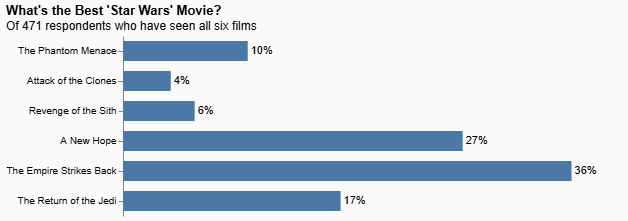

In [44]:
# test your code
genBestVis(sw,episodes)



## Make sure to *style* your visualization to match the original the best you can

We can also drill down and find out, generally, how people rate the films. Overall, fans broke into two camps: those who preferred the original three movies and those who preferred the three prequels. People who said “The Empire Strikes Back” was their favorite were also likely to rate “A New Hope” and “Return of the Jedi” higher as well. Those who rated “The Phantom Menace” as the best film were more likely to rate prequels higher.

This chart shows how often each film was rated in the top third (best or second-best), the middle third (third or fourth) or the bottom third (second-worst or worst). It’s a more nuanced take on the series:

!["Sol1"](/voc/data/how_rate_resized.png)

** Homework note: Click [here](/voc/data/people_rate.png) to see a version of this plot generated in Altair.

### 2.2 How people rate the 'Star Wars' movie? Recreate the above image using altair (10 Points)

In [45]:
#HELPER FUNCTIONS
def genBinDF(inpf, eps=episodes, names=namesDict, names_l=namesList):
    total = len(inpf)

    summary = []

    for ep in eps:
        rank_ep = 'rank_' + ep
        top = (pd.to_numeric(inpf[rank_ep], errors='coerce').isin([1,2])).sum() / total
        mid = (pd.to_numeric(inpf[rank_ep], errors='coerce').isin([3,4])).sum() / total
        bottom = (pd.to_numeric(inpf[rank_ep], errors='coerce').isin([5,6])).sum() / total

        summary.append({
            'Episode': names[ep],
            'Top third': top,
            'Middle third': mid,
            'Bottom third': bottom
        })

    rank_summary = pd.DataFrame(summary)

    return rank_summary


def make_bar(base, rank, color, tick=False, show_y=False, names_l=namesList):
    #input: base - base viz
    #input: rank - column name (the top/middle/bottom thirds)
    #input: color - dict to match colors
    #input: show_y - show y axis label if True
    #output: horizontal bar chart
    bar = base.transform_filter(
        alt.datum.Rank == rank
    ).mark_bar(size=14).encode(
        x=alt.X('Percent:Q',
                scale=alt.Scale(domain=[0, 0.7]),
                axis=None),
        color=alt.value(color),
        y=alt.Y('Episode:N', sort=names_l,
                axis=alt.Axis(title=None, labels=show_y, domain=False, ticks=tick))
    )

    # Add text labels
    text = base.transform_filter(
        alt.datum.Rank == rank
    ).mark_text(
        align='left',
        dx=3,
        fontSize=11,
        color=color
    ).encode(
        x=alt.X('Percent:Q', scale=alt.Scale(domain=[0, 0.7])),
        y=alt.Y('Episode:N', sort=names_l),
        text=alt.Text('Percent:Q', format='.0%')
    )

    # Add column title above
    titled = alt.layer(bar, text).properties(
        title=rank,
        width=100,
        height=150,
        view={'stroke': None}
    )

    return titled

In [46]:
# Recreate this image using altair here (10 POINTS)

def genRateVis(inpf,eps, names=namesDict, names_l=namesList):
    # input: inpf, the star wars dataset
    # input: eps, the list of episodes
    # input: names - a dictionary of abbreviations to names (default: namesDict)
    # input: names_l - a list of all the movies in series order (default: namesList)
    # output: the Altair visualization as described above
    
    # Keep people who have seen all 6 films
    seenallDF = SeenAllDF(inpf, eps)

    # Create bins for rank and build df
    percentDF = genBinDF(seenallDF)

    # Elongate DF
    baseDF = percentDF.melt(id_vars='Episode', var_name='Rank', value_name='Percent')
                            
    # Assign colors
    colors = {
        'Top third': '#4CAF50',    # green
        'Middle third': '#42A5F5', # blue
        'Bottom third': '#F44336'  # red
    }
    
    # Generate base vis    
    base = alt.Chart(baseDF).encode(
        y=alt.Y(
            'Episode:N',
            sort=names_l,
            axis=alt.Axis(title=None)
            )
        )
    
    # Create top/middle/bottom bar charts
    top = make_bar(base, 'Top third', colors['Top third'], show_y=True, tick=True)
    mid = make_bar(base, 'Middle third', colors['Middle third'], show_y=False)
    bot = make_bar(base, 'Bottom third', colors['Bottom third'], show_y=False)

    # Combine charts (side-by-side)
    chart = alt.hconcat(
        top,
        mid,
        bot
    ).resolve_scale(y='shared').properties(
        title=alt.TitleParams(
            text="How People Rate the 'Star Wars' Movies",
            subtitle=["How often each film was rated in the top, middle and bottom third","(Of 471 respondents who have seen all six films)"],
            fontSize=16,
            fontWeight="bold",
            align="left",
            anchor="start",
            dy=-10
        )
    ).configure_view(
        stroke=None,
        fill='#fafafa'
    ).configure(
        background='#fafafa'
    ).configure_scale(bandPaddingInner = 0.1)

    return(chart)
            
    

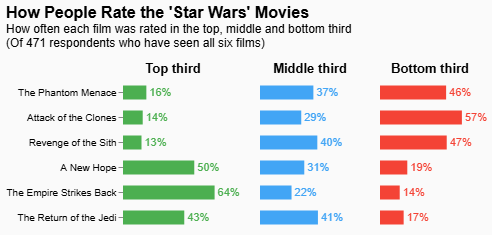

In [47]:
# let's check our solution
genRateVis(sw,episodes)

Finally, we took a boilerplate format used by political favorability polls — “Please state whether you view the following characters favorably, unfavorably, or are unfamiliar with him/her” — and asked respondents to rate characters in the series.

!["Sol1"](/voc/data/char_ranking_resized.png)


** Homework note. Here's an example solution generated in Altair:
!["Sol1"](/voc/data/people_rate_s.png)

Be careful here in what you're dividing by to get the totals for each character.

### 2.3 Star Wars' Characters Favorability Ratings. Recreate the above image using altair (10 Points)

In [48]:
characterlist = ['Luke Skywalker','Han Solo','Princess Leia Organa','Obi Wan Kenobi','Yoda','R2 D2','C-3P0','Anakin Skywalker','Darth Vader','Lando Calrissian','Padme Amidala','Boba Fett','Emperor Palpatine','Jar Jar Binks']
favor = ['Very favorably','Somewhat favorably']
nue = 'Neither favorably nor unfavorably (neutral)'
unfavor = ['Somewhat unfavorably','Very unfavorably']
unfam = 'Unfamiliar (N/A)'

def FavorableDF(inpf, chars=characterlist):
    # input: inpf - dataframe to be manipulated
    # input: chars - list of columns (character list)
    # output: dataframe that has character
    
    summary = []
    
    for char in chars:
        total = inpf[char].notna().sum()
        favor_perc = inpf[char].isin(favor).sum() / total
        nue_perc = (inpf[char] == nue).sum() / total
        unfavor_perc = inpf[char].isin(unfavor).sum() / total
        unfam_perc = (inpf[char] == unfam).sum() / total

        summary.append({
            'Character': char,
            'Favorable': favor_perc,
            'Nuetral': nue_perc,
            'Unfavorable': unfavor_perc,
            'Unfamiliar': unfam_perc
        })            
    
    favorability_summary = pd.DataFrame(summary).sort_values(
        by='Favorable', ascending=False
    )
    
    
    return favorability_summary



def favor_bar(base, favor, color, tick=False, show_y=False, sort=characterlist):
    #input: base - base viz
    #input: rank - column name (the top/middle/bottom thirds)
    #input: color - dict to match colors
    #input: show_y - show y axis label if True
    #output: horizontal bar chart
    bar = base.transform_filter(
        alt.datum.Favorability == favor
    ).mark_bar(size=16).encode(
        x=alt.X('Percent:Q',
                scale=alt.Scale(domain=[0, 1.0]),
                axis=None),
        color=alt.value(color),
        y=alt.Y('Character:N', sort=sort,
                axis=alt.Axis(title=None, labels=show_y, domain=False, ticks=tick))
    )

    # Add text labels
    text = base.transform_filter(
        alt.datum.Favorability == favor
    ).mark_text(
        align='left',
        dx=3,
        fontSize=11,
        color=color
    ).encode(
        x=alt.X('Percent:Q', scale=alt.Scale(domain=[0, 1.0])),
        y=alt.Y('Character:N', sort=sort),
        text=alt.Text('Percent:Q', format='.0%')
    )

    # Add column title above
    titled = alt.layer(bar, text).properties(
        title=alt.TitleParams(text=favor,fontWeight='normal',fontSize=12),
        width=100,
        height=len(sort)*20,
        view={'stroke': None}
    )

    return titled

In [49]:
# Recreate this image using altair here (10 POINTS)

def genFavorabilityVis(inpf):
    # input: inpf, the star wars dataset (as defined at top of file)
    # output: the Altair visualization as described above
    
    #Create Cleaned DataFrame and elongate
    FavorScoreDF = FavorableDF(inpf)
    baseDF = FavorScoreDF.melt(id_vars='Character', var_name='Favorability', value_name='Percent')
    # Assign colors
    colors = {
        'Favorable': '#4CAF50',    # green
        'Nuetral': '#42A5F5', # blue
        'Unfavorable': '#F44336',  # red
        'Unfamiliar': '#959595' #dark gray
    }

    # Create Sort Order
    sort_order = FavorScoreDF['Character'].unique().tolist()
    
    # Generate base vis    
    base = alt.Chart(baseDF).encode(
        y=alt.Y(
            'Character:N',
            sort=sort_order,
            axis=alt.Axis(title=None)
            )
        )
    # Generate favorability charts
    favor = favor_bar(base, 'Favorable', colors['Favorable'], tick=True, show_y=True)
    nuetral = favor_bar(base, 'Nuetral', colors['Nuetral'])
    unfavor = favor_bar(base, 'Unfavorable', colors['Unfavorable'])
    unfamiliar = favor_bar(base, 'Unfamiliar', colors['Unfamiliar'])

    # Combine charts (side-by-side)
    chart = alt.hconcat(
        favor,
        nuetral,
        unfavor,
        unfamiliar
    ).resolve_scale(
        y='shared'
    ).properties(
        spacing=5,
        title=alt.TitleParams(
            text="'Star Wars' Characters Favorability Ratings",
            subtitle=["By 834 Respondents"],
            fontSize=18,
            fontWeight="bold",
            align="left",
            anchor="start",
            dy=-10
        )
    ).configure_view(
        stroke=None,
        fill='#fafafa'
    ).configure(
        background='#fafafa'
    ).configure_scale(
        bandPaddingInner=0.2,
    )
    
    return chart

    

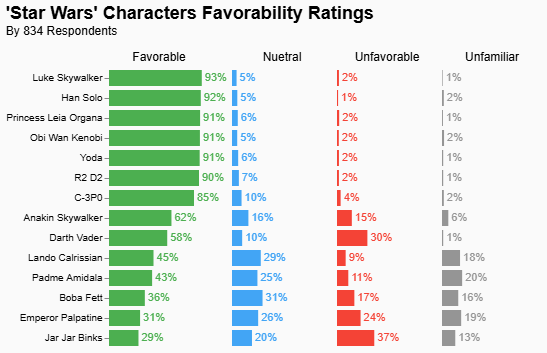

In [50]:
# let's test the solution
genFavorabilityVis(sw)

!["Sol1"](/voc/data/shot_first_article_resized.png)


** Homework note: Click [here](/voc/data/shot_first.png) to see a version of this plot generated in Altair. You may find that you don't get 834 rows (as 538 did) but the percents should still work.

### 2.4 Who shot first? Recreate the above image using altair (10 Points)

In [51]:
# Recreate this image using altair here (10 POINTS)

def genFirstShotVis(inpf):
    # input: inpf, the star wars dataset
    # output: the Altair visualization as described above
    
    # Clean DF
    inpf = inpf.rename(columns={'Which character shot first?':'Answer'})
    cleanDF = inpf.dropna(subset='Answer')
    
    # Create percentage DF
    pivot = pd.pivot_table(
        cleanDF,
        index= 'Answer',
        aggfunc='size'
    )
    percentDF = (pivot / pivot.sum()).reset_index(name='Percent')
    
    # Define sort order and sort
    sort = ['Han', 'Greedo', "I don't understand this question"]
    percentDF['Answer'] = pd.Categorical(
        percentDF['Answer'],
        categories=sort,
        ordered=True
    )
    percentDF = percentDF.sort_values('Answer').reset_index(drop=True)

    # Generate Base Viz
    base = alt.Chart(percentDF).mark_bar(size=20, color='#42A5F5').encode(
        y=alt.Y(
            'Answer:N',
            sort=sort,
            axis=alt.Axis(title=None)
            ),
        x=alt.X(
            'Percent:Q',
            axis= None
        )
    ).properties(
        view={'stroke': None}
    )

    #Add text
    text = base.mark_text(
        align='left',
        baseline='middle',
        dx=3
    ).encode(
        text=alt.Text('Percent:Q',format='.0%')
    )

    # Combine Layers
    Shotfirst = (text + base).configure_mark(
        color='#42A5F5'
    ).configure_view(
        strokeWidth=0,
        fill='#fafafa'
    ).configure(
        background='#fafafa'
    ).configure_scale(
        bandPaddingInner=0.2
    ).properties(
        title=alt.TitleParams(
            text='Who Shot First?',
            subtitle='According to 828 respondents',
            fontSize=16,
            fontWeight='bold',
            align='left',
            anchor='start',
            dy=-15
        ),
        width=679,
        height=100
    )
    
    
    
    return Shotfirst

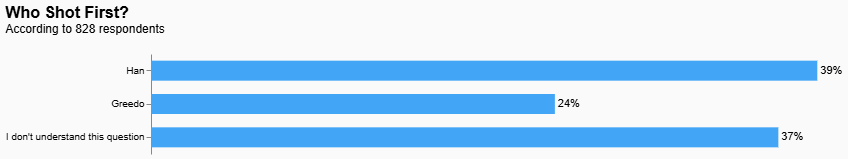

In [52]:
# test our solution
genFirstShotVis(sw)

### 2.5 Make your own (35 points total - 20 for implementation, 15 for justification)

Reading through the article, identify some aspect of the story that would benefit from an extra visualization (you can imagine extending the article if it helps). We would like for you to create two versions of this hypothetical visualization.  You should be able to convincingly argue that one visualization is better than the other.

Note: The two visualizations should use different marks and at least some of the encodings should be different. If you're struggling with coming up with two really different representations, your visualization may simply be too simple. Try to add additional columns/comparisons. 

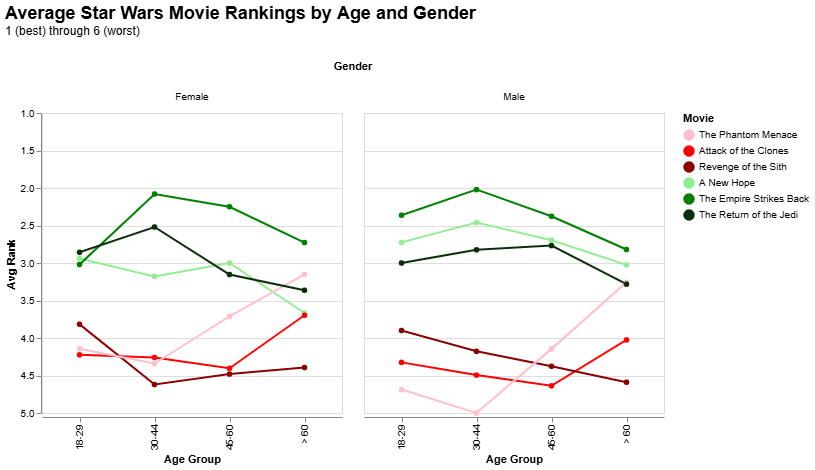

In [53]:
# Viz 1

def Viz1(inpf, names=namesDict, sort=namesList):
    AllDF = SeenAllDF(inpf)

    rank_cols = ['rank_' + ep for ep in episodes]
    
    long_df = AllDF.melt(
        id_vars=['Gender', 'Age'],
        value_vars=rank_cols,
        var_name='Movie',
        value_name='Rank'
    )

    long_df['Movie'] = long_df['Movie'].str.replace('rank_', '').map(names)
    long_df['Rank'] = pd.to_numeric(long_df['Rank'], errors='coerce')

    # Compute mean rank
    agg = long_df.groupby(['Movie', 'Gender', 'Age'], as_index=False)['Rank'].mean()

    # Define colors for each movie
    movie_colors = {
        'The Phantom Menace': 'pink',
        'Attack of the Clones': 'red',
        'Revenge of the Sith': 'darkred',
        'A New Hope': 'lightgreen',
        'The Empire Strikes Back': 'green',
        'The Return of the Jedi': '#0a2e0a'
    }

    # Build grouped bar chart
    chart = alt.Chart(agg).mark_line(point=True).encode(
        x=alt.X('Age:N', title='Age Group'),
        y=alt.Y('Rank:Q', title='Avg Rank', scale=alt.Scale(domain=[1,5], reverse=True)),
        color=alt.Color('Movie:N', scale=alt.Scale(domain=list(movie_colors.keys()), range=list(movie_colors.values()))),
        column=alt.Column('Gender:N', title='Gender'),
        tooltip=['Movie', 'Gender', 'Age', 'Rank']
    ).properties(
        title=alt.TitleParams(
            text='Average Star Wars Movie Rankings by Age and Gender',
            subtitle='1 (best) through 6 (worst)',
            fontSize=18,
            fontWeight='bold',
            dy=-20
        ),
        width=300
    )

    return chart

Viz1(sw)

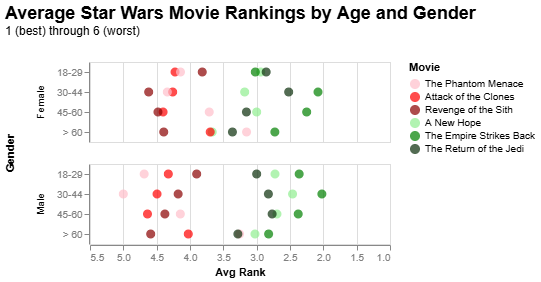

In [54]:
# Viz 2

def Viz2(inpf, names=namesDict, sort=namesList):
    AllDF = SeenAllDF(inpf)

    rank_cols = ['rank_' + ep for ep in episodes]
    
    long_df = AllDF.melt(
        id_vars=['Gender','Age'],
        value_vars = rank_cols,
        var_name = 'Movie',
        value_name='Rank'
    )

    long_df['Movie'] = long_df['Movie'].str.replace('rank_','').map(names)

    # Compute Mean Rank
    long_df['Rank'] = pd.to_numeric(long_df['Rank'], errors='coerce')
    agg = long_df.groupby(['Movie','Gender','Age'], as_index=False)['Rank'].mean()
        

    # Define Colors for Age Group
    movie_colors = {
        'The Phantom Menace': 'pink',  
        'Attack of the Clones': 'red',  
        'Revenge of the Sith': 'darkred',  
        'A New Hope': 'lightgreen',
        'The Empire Strikes Back': 'green',
        'The Return of the Jedi': '#0a2e0a' #darkgreen
        }
    
    # Build Chart
    chart = alt.Chart(agg).mark_point(filled=True, size=80).encode(
        x=alt.X(
            'Rank:Q',
            title='Avg Rank',
            scale=alt.Scale(domain=[1,5.5],reverse=True)
        ),
        y=alt.Y(
            'Age:N',
            title=None
        ),
        color=alt.Color(
            'Movie:N',
            scale=alt.Scale(
                domain=list(movie_colors.keys()),
                range=list(movie_colors.values())
            )
        ),
        row=alt.Row('Gender:N', title='Gender'),
        tooltip=['Movie', 'Gender', 'Age', 'Rank']
    ).properties(
        title=alt.TitleParams(
            text='Average Star Wars Movie Rankings by Age and Gender',
            subtitle='1 (best) through 6 (worst)',
            fontSize=18,
            fontWeight='bold',
            dy=-20
        ),
        width=300
    ).configure_axis(
        labelColor='gray',
        titleColor='black'
    )
        
        
    return(chart)

Viz2(sw)

#### Justification
*Provide your justification here* to argue why your "better" version is actually better. Make sure to defend this based on expressiveness and effectiveness as well as perceptual arguments.

Overall, the better visualization is the dot plot as it more effectively utilizes the viewers perceptual processing abilities. This leads to quicker, more accurate insights while requiring much less cognitive load from the viewer.

| Criteria | Line Chart (Viz1) | Dot Plot (Viz2, BETTER) |
|---|---|---|
| Expressiveness | The lines across age groups imply a trend across ages, which can falsely suggest that rank changes continuously with age | Treats age groups as discrete categories. Correctly expresses the data because it encodes the variable type more accurately |
| Effectiveness | Visually cluttered because it is harder to decode which line belongs to which movie, espcially when the lines overlap. Also cluttered because it uses redundant legends and requires more visual tracking | Less visual clutter. Creates clearer groupings making it easier to decode and compare movies within each demographic. |
| Visual Encoding | relies on position + line + color causing the decoding of rank differences require mental estimation of the y-positions. | Uses only two encodings (x and color), both of which are strong for quantitative and nominal/ordinal data.|
| Preattentive Processing | line implies sequential scanning causing patterns to emerge slower and even incorrectly. This also requires more cognitive load as you have to track multiple colored lines across facets. | Color and position differences are preceived almost instantly. Because each point encodes one value, it is simple and direct leading to low cognitive load. |


Example Domain Task: "Compare how males and females rank the two trilogies"  
It is easier to see the separation that males, on average, rank the first trilogy much higher than the second when looking at the dot plot. It is much harder to identify that pattern when looking at the line chart due to the clutter and need for much more active decoding.
